In [1]:
import pandas as pd
import numpy as np
import pickle

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

import sklearn

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from imblearn.over_sampling import SMOTE

plt.style.use("fivethirtyeight")

c:\Users\91955\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\91955\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [4]:
data = pd.read_csv("loan_prediction.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


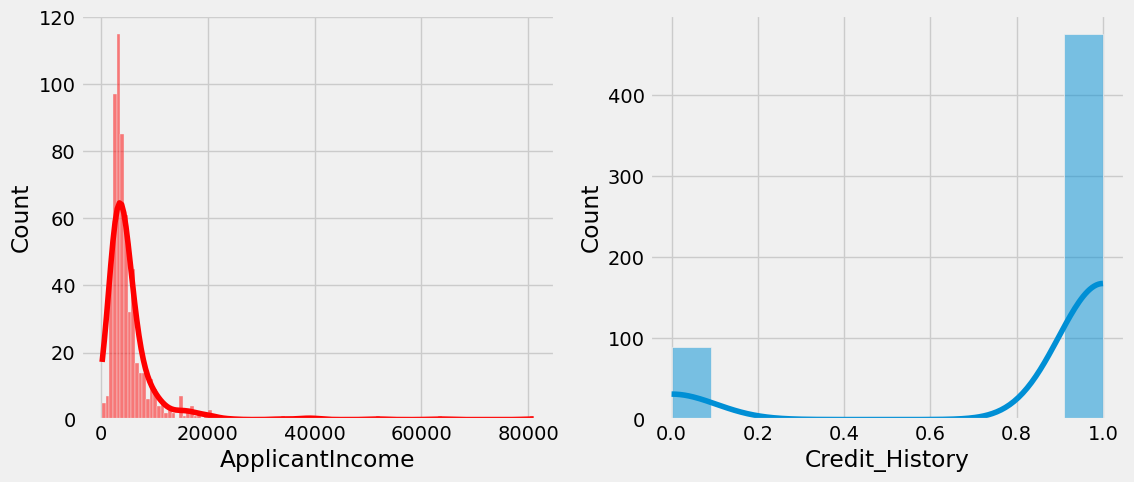

In [5]:
plt.figure(figsize=(12,5))

plt.subplot(121)
sns.histplot(data['ApplicantIncome'], kde=True, color='r')

plt.subplot(122)
sns.histplot(data['Credit_History'], kde=True)

plt.show()

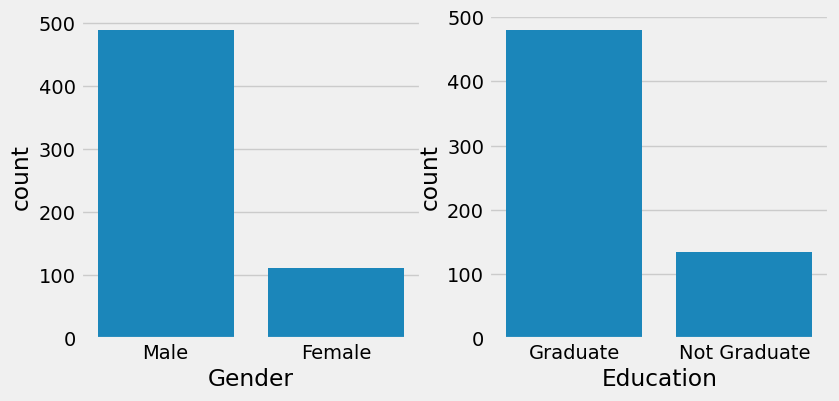

In [6]:
# plotting the count plot

plt.figure(figsize=(18,4))

plt.subplot(1,4,1)
sns.countplot(x=data['Gender'])

plt.subplot(1,4,2)
sns.countplot(x=data['Education'])

plt.show()

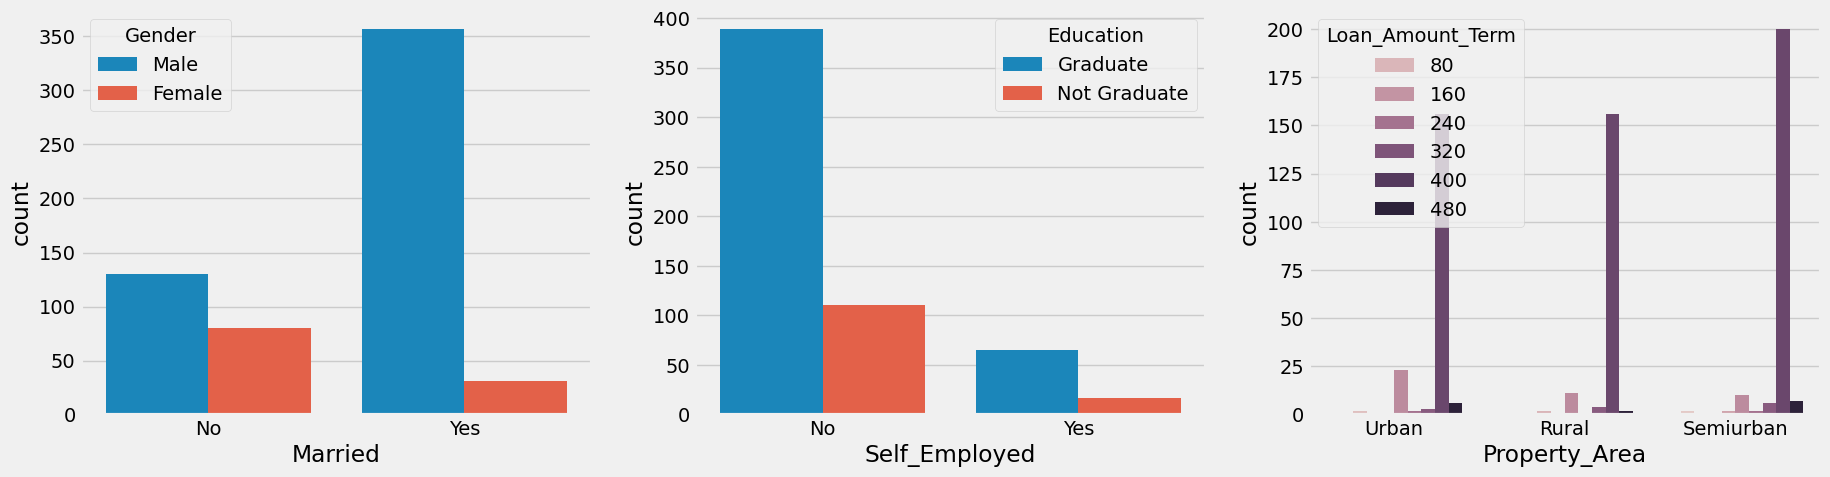

In [7]:
# visualising two columns against each other

plt.figure(figsize=(20,5))

plt.subplot(131)
sns.countplot(x=data['Married'], hue=data['Gender'])

plt.subplot(132)
sns.countplot(x=data['Self_Employed'], hue=data['Education'])

plt.subplot(133)
sns.countplot(x=data['Property_Area'], hue=data['Loan_Amount_Term'])

plt.show()

c:\Users\91955\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 22.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\91955\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 46.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


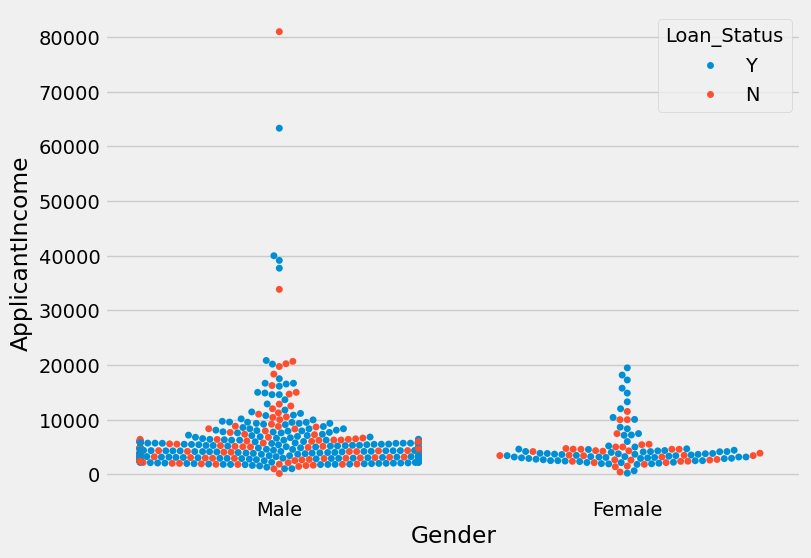

In [8]:
plt.figure(figsize=(8,6))

sns.swarmplot(
    x='Gender',
    y='ApplicantIncome',
    hue='Loan_Status',
    data=data
)

plt.show()

In [9]:
# finding the sum of null values in each column
data.isnull().sum()

data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])

data['Married'] = data['Married'].fillna(data['Married'].mode()[0])

# replacing + with space for filling the nan values
data['Dependents'] = data['Dependents'].str.replace('+', '', regex=False)

data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])

data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])

data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].mode()[0])

data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0])

data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             614 non-null    str    
 2   Married            614 non-null    str    
 3   Dependents         614 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      614 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.2 KB


In [10]:
# Handling categorical values

data['Gender'] = data['Gender'].map({'Female': 1, 'Male': 0})

data['Property_Area'] = data['Property_Area'].map({
    'Urban': 2,
    'Semiurban': 1,
    'Rural': 0
})

data['Married'] = data['Married'].map({
    'Yes': 1,
    'No': 0
})

data['Education'] = data['Education'].map({
    'Graduate': 1,
    'Not Graduate': 0
})

data['Loan_Status'] = data['Loan_Status'].map({
    'Y': 1,
    'N': 0
})

data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0,0,0,1,No,5849,0.0,120.0,360.0,1.0,2,1
1,LP001003,0,1,1,1,No,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,0,1,0,1,Yes,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,0,1,0,0,No,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,0,0,0,1,No,6000,0.0,141.0,360.0,1.0,2,1


In [11]:
# Remove Loan_ID column if it exists
if 'Loan_ID' in data.columns:
    data = data.drop('Loan_ID', axis=1)

# Create Features and Target
x = data.drop('Loan_Status', axis=1)
y = data['Loan_Status']

In [12]:
print(data.columns)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')


In [13]:
print(x.select_dtypes(include='object').columns)

Index(['Dependents', 'Self_Employed'], dtype='str')


C:\Users\91955\AppData\Local\Temp\ipykernel_29468\4015513626.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(x.select_dtypes(include='object').columns)


In [14]:
# Convert Dependents to numeric
data['Dependents'] = data['Dependents'].replace('3+', '3')
data['Dependents'] = pd.to_numeric(data['Dependents'])

# Convert Self_Employed to numeric
data['Self_Employed'] = data['Self_Employed'].map({'No': 0, 'Yes': 1})
data['Self_Employed'] = data['Self_Employed'].fillna(0).astype(int)

In [15]:
x = data.drop('Loan_Status', axis=1)
y = data['Loan_Status']

print(x.select_dtypes(include='object').columns)

Index([], dtype='str')


In [24]:
smote = SMOTE(random_state=42)
x_bal, y_bal = smote.fit_resample(x, y)

sc = StandardScaler()
names = x.columns
x_bal = pd.DataFrame(sc.fit_transform(x_bal), columns=names)

In [25]:
# Splitting the dataset into train and test on balanced dataset

X_train, X_test, y_train, y_test = train_test_split(
    x_bal,
    y_bal,
    test_size=0.33,
    random_state=42
)

X_train.shape

X_test.shape

(279, 11)

In [26]:
# importing and building the Decision Tree model

def decisionTree(X_train, X_test, y_train, y_test):
    model = DecisionTreeClassifier(random_state=42)

    model.fit(X_train, y_train)

    y_tr = model.predict(X_train)
    print("Train Accuracy:", accuracy_score(y_train, y_tr))

    yPred = model.predict(X_test)
    print("Test Accuracy:", accuracy_score(y_test, yPred))

    return model

In [27]:
decisionTree(X_train, X_test, y_train, y_test)

Train Accuracy: 1.0
Test Accuracy: 0.7956989247311828


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [28]:
# importing and building the Random Forest model

def RandomForest(X_train, X_test, y_train, y_test):
    model = RandomForestClassifier(random_state=42)

    model.fit(X_train, y_train)

    y_tr = model.predict(X_train)
    print("Train Accuracy:", accuracy_score(y_train, y_tr))

    yPred = model.predict(X_test)
    print("Test Accuracy:", accuracy_score(y_test, yPred))

    return model

In [29]:
rf_model = RandomForest(X_train, X_test, y_train, y_test)

Train Accuracy: 1.0
Test Accuracy: 0.7921146953405018


In [30]:
# importing and building the KNN model

def KNN(X_train, X_test, y_train, y_test):
    model = KNeighborsClassifier()

    model.fit(X_train, y_train)

    y_tr = model.predict(X_train)
    print("Train Accuracy:", accuracy_score(y_train, y_tr))

    yPred = model.predict(X_test)
    print("Test Accuracy:", accuracy_score(y_test, yPred))

    return model

In [31]:
KNN(X_train, X_test, y_train, y_test)

Train Accuracy: 0.8442477876106195
Test Accuracy: 0.7060931899641577


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [32]:
# importing and building the Gradient Boosting model

def XGB(X_train, X_test, y_train, y_test):
    model = GradientBoostingClassifier(random_state=42)

    model.fit(X_train, y_train)

    y_tr = model.predict(X_train)
    print("Train Accuracy:", accuracy_score(y_train, y_tr))

    yPred = model.predict(X_test)
    print("Test Accuracy:", accuracy_score(y_test, yPred))

    return model

In [33]:
XGB(X_train, X_test, y_train, y_test)

Train Accuracy: 0.9309734513274336
Test Accuracy: 0.7921146953405018


,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [ ]:
import pickle

pickle.dump(rf_model, open("rdf.pkl", "wb"))

pickle.dump(sc, open("scale1.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully
